In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup

# Exemplo com 3 lojas - você troca o produto
produtos = [
    {"produto": "Smartphone Samsung", "loja": "Loja A", "preco": 1899.90, "link": "link.com"},
    {"produto": "Smartphone Samsung", "loja": "Loja B", "preco": 1750.00, "link": "link.com"},
    {"produto": "Smartphone Samsung", "loja": "Loja C", "preco": 1999.90, "link": "link.com"},
]

df = pd.DataFrame(produtos)
df.head()

,produto,loja,preco,link
0,Smartphone Samsung,Loja A,1899.9,link.com
1,Smartphone Samsung,Loja B,1750.0,link.com
2,Smartphone Samsung,Loja C,1999.9,link.com


In [ ]:
# Simulando dados sujos como na vida real
df['preco'] = df['preco'].astype(str).str.replace('R$', '').str.strip()
df['preco'] = pd.to_numeric(df['preco'], errors='coerce')

df = df.dropna() # valores ausentes
df = df.drop_duplicates() # duplicatas
df['produto'] = df['produto'].str.lower().str.strip() # padronização
df['data_coleta'] = pd.to_datetime('today')

df_clean = df
df_clean

,produto,loja,preco,link,data_coleta
0,smartphone samsung,Loja A,1899.9,link.com,2026-09-23 19:03:44.763002
1,smartphone samsung,Loja B,1750.0,link.com,2026-09-23 19:03:44.763002
2,smartphone samsung,Loja C,1999.9,link.com,2026-09-23 19:03:44.763002


In [ ]:
# Menor preço, média, diferença
analise = df_clean.groupby('produto').agg(
    menor_preco=('preco', 'min'),
    maior_preco=('preco', 'max'),
    media_preco=('preco', 'mean'),
    qtd_lojas=('loja', 'count')
).reset_index()

analise['economia'] = analise['maior_preco'] - analise['menor_preco']
analise

,produto,menor_preco,maior_preco,media_preco,qtd_lojas,economia
0,smartphone samsung,1750.0,1999.9,1883.266667,3,249.9


In [ ]:
import sqlite3

# Cria banco SQL
conn = sqlite3.connect('comparador_precos.db')
df_clean.to_sql('precos', conn, if_exists='replace', index=False)
analise.to_sql('analise', conn, if_exists='replace', index=False)

# Exporta CSV pra Power BI
df_clean.to_csv('precos_tratados.csv', index=False)
analise.to_csv('analise_precos.csv', index=False)

print("Banco e CSVs criados!")

Banco e CSVs criados!


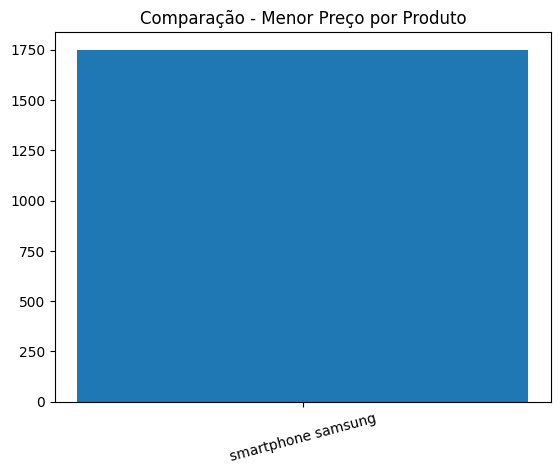

In [ ]:
import matplotlib.pyplot as plt

plt.bar(analise['produto'], analise['menor_preco'])
plt.title('Comparação - Menor Preço por Produto')
plt.xticks(rotation=15)
plt.show()